# MScFE 622 Stochastic Modeling — Group Work Project #2
## VIX-Regime Allocation across TLT, GLD, and SPY

This is the canonical technical report notebook. It deliberately contains **no analysis implementation**: calculations, validation, file loading, formatting, and figure presentation live in tested helper modules under `src/vix_regime_allocation/`. Notebook code cells are restricted to one import and one-line helper calls so that the mathematical reasoning and empirical interpretation remain visually separate from implementation details.

The empirical design uses daily Yahoo Finance adjusted closes over the maximum common sample, daily ETF log returns, and the daily first difference of VIX. It compares two- and three-state quantile Markov specifications with two- and three-state Gaussian hidden-state specifications, selects the preferred regime representation using the pre-declared decision rule, maps each selected state to the ETF with the largest historical conditional mean return, and evaluates the resulting one-row-lagged allocation against monthly equal weight and SPY buy-and-hold benchmarks.


In [1]:
import vix_regime_allocation.notebook_helpers as nb

## 1. Data preparation and exploratory analysis

The market sample contains TLT, GLD, SPY, and VIX only on dates for which all four adjusted-close observations are present. No forward fill, backward fill, or interpolation is used. Adjusted closes are appropriate for the ETF return series because they incorporate distribution and split adjustments supplied by the data source; the VIX series is treated as the published index level rather than as a tradable asset price.

The VIX is a forward-looking option-implied measure of expected S&P 500 volatility over approximately the next 30 days, not a forecast of the direction of the equity index (Whaley 98–105; Cboe Global Markets).

<!-- citekey: whaley2009vix -->
<!-- citekey: cboe2019vixfaq -->

### ETF log returns
For ETF \(i\) on observed trading row \(t\), the daily log return is

\[
r_{i,t}=\ln\!\left(\frac{P_{i,t}}{P_{i,t-1}}\right).
\]

Here \(P_{i,t}\) is the adjusted close and \(r_{i,t}\) is the continuously compounded one-period return. Log returns are additive across time, while portfolio arithmetic in the backtest later uses simple returns obtained by \(R_{i,t}=e^{r_{i,t}}-1\).

### VIX change
**Greek letter used below:** \(\Delta\) — *Delta* — denotes a first difference.

\[
\Delta VIX_t = VIX_t-VIX_{t-1}.
\]

Using the change rather than the level makes the state variable represent the direction and magnitude of daily volatility shocks: negative values indicate falling implied volatility and positive values indicate rising implied volatility.


In [2]:
nb.show_step1_sample()

**First five observations of the canonical common sample**

,TLT,GLD,SPY,VIX,TLT_log_return,GLD_log_return,SPY_log_return,VIX_change
Date,,,,,,,,
2004-11-19,43.302605,44.779999,78.858780,13.50,-0.008012,0.008973,-0.011178,0.520000
2004-11-22,43.528297,44.950001,79.234833,12.97,0.005198,0.003789,0.004757,-0.530000
2004-11-23,43.582287,44.750000,79.355743,12.67,0.001240,-0.004459,0.001525,-0.300000
2004-11-24,43.582287,45.049999,79.543793,12.72,0.000000,0.006682,0.002367,0.050000
2004-11-26,43.297714,45.290001,79.483330,12.78,-0.006551,0.005313,-0.000760,0.059999


**Sample integrity summary**

,value
start_date,2004-11-19
end_date,2026-08-17
observations,5465
missing_values,0


The common sample contains **5,465 daily observations** from **2004-11-19** through **2026-08-17**, with no missing values after the common-date filter and lag construction.

**ETF daily log returns**

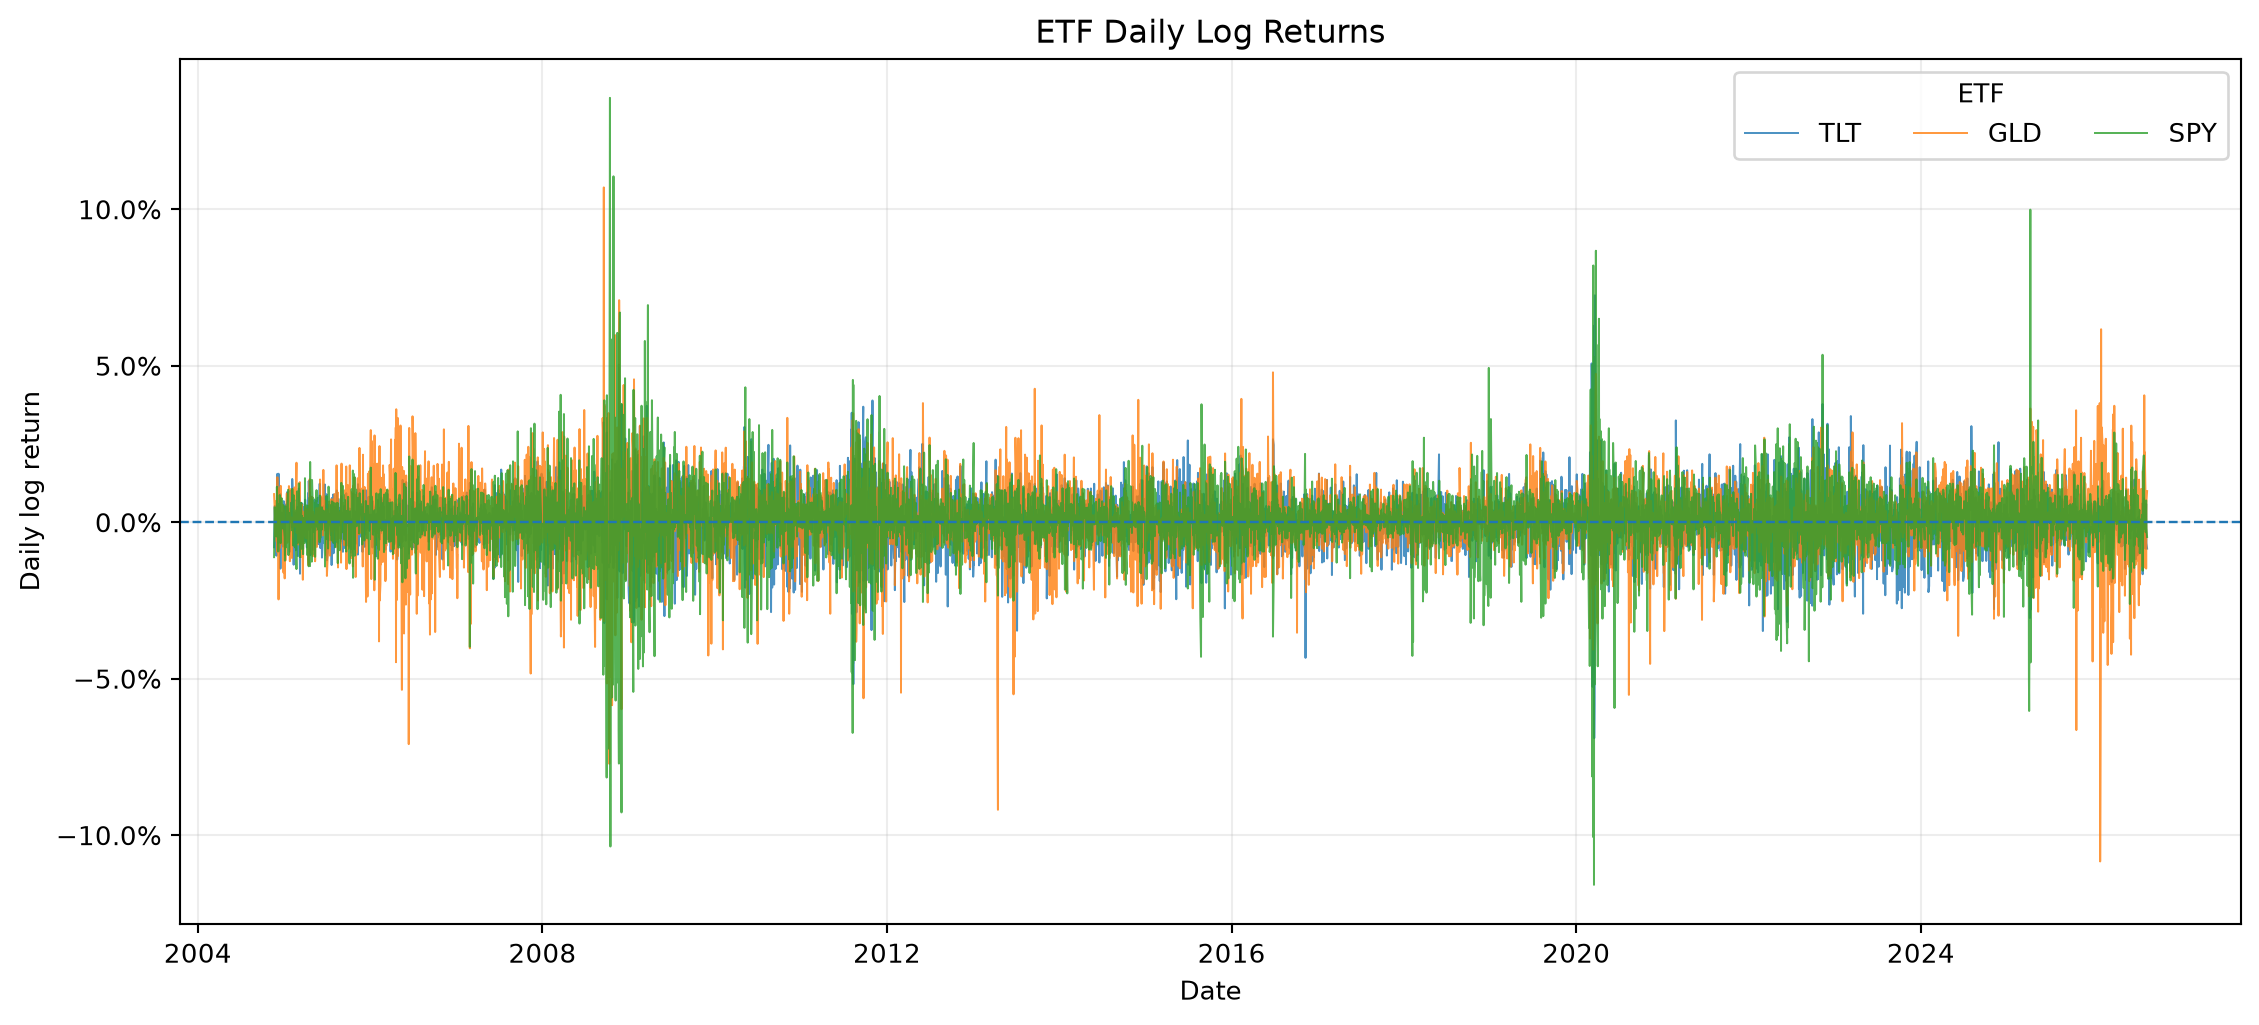

**Daily VIX first difference**

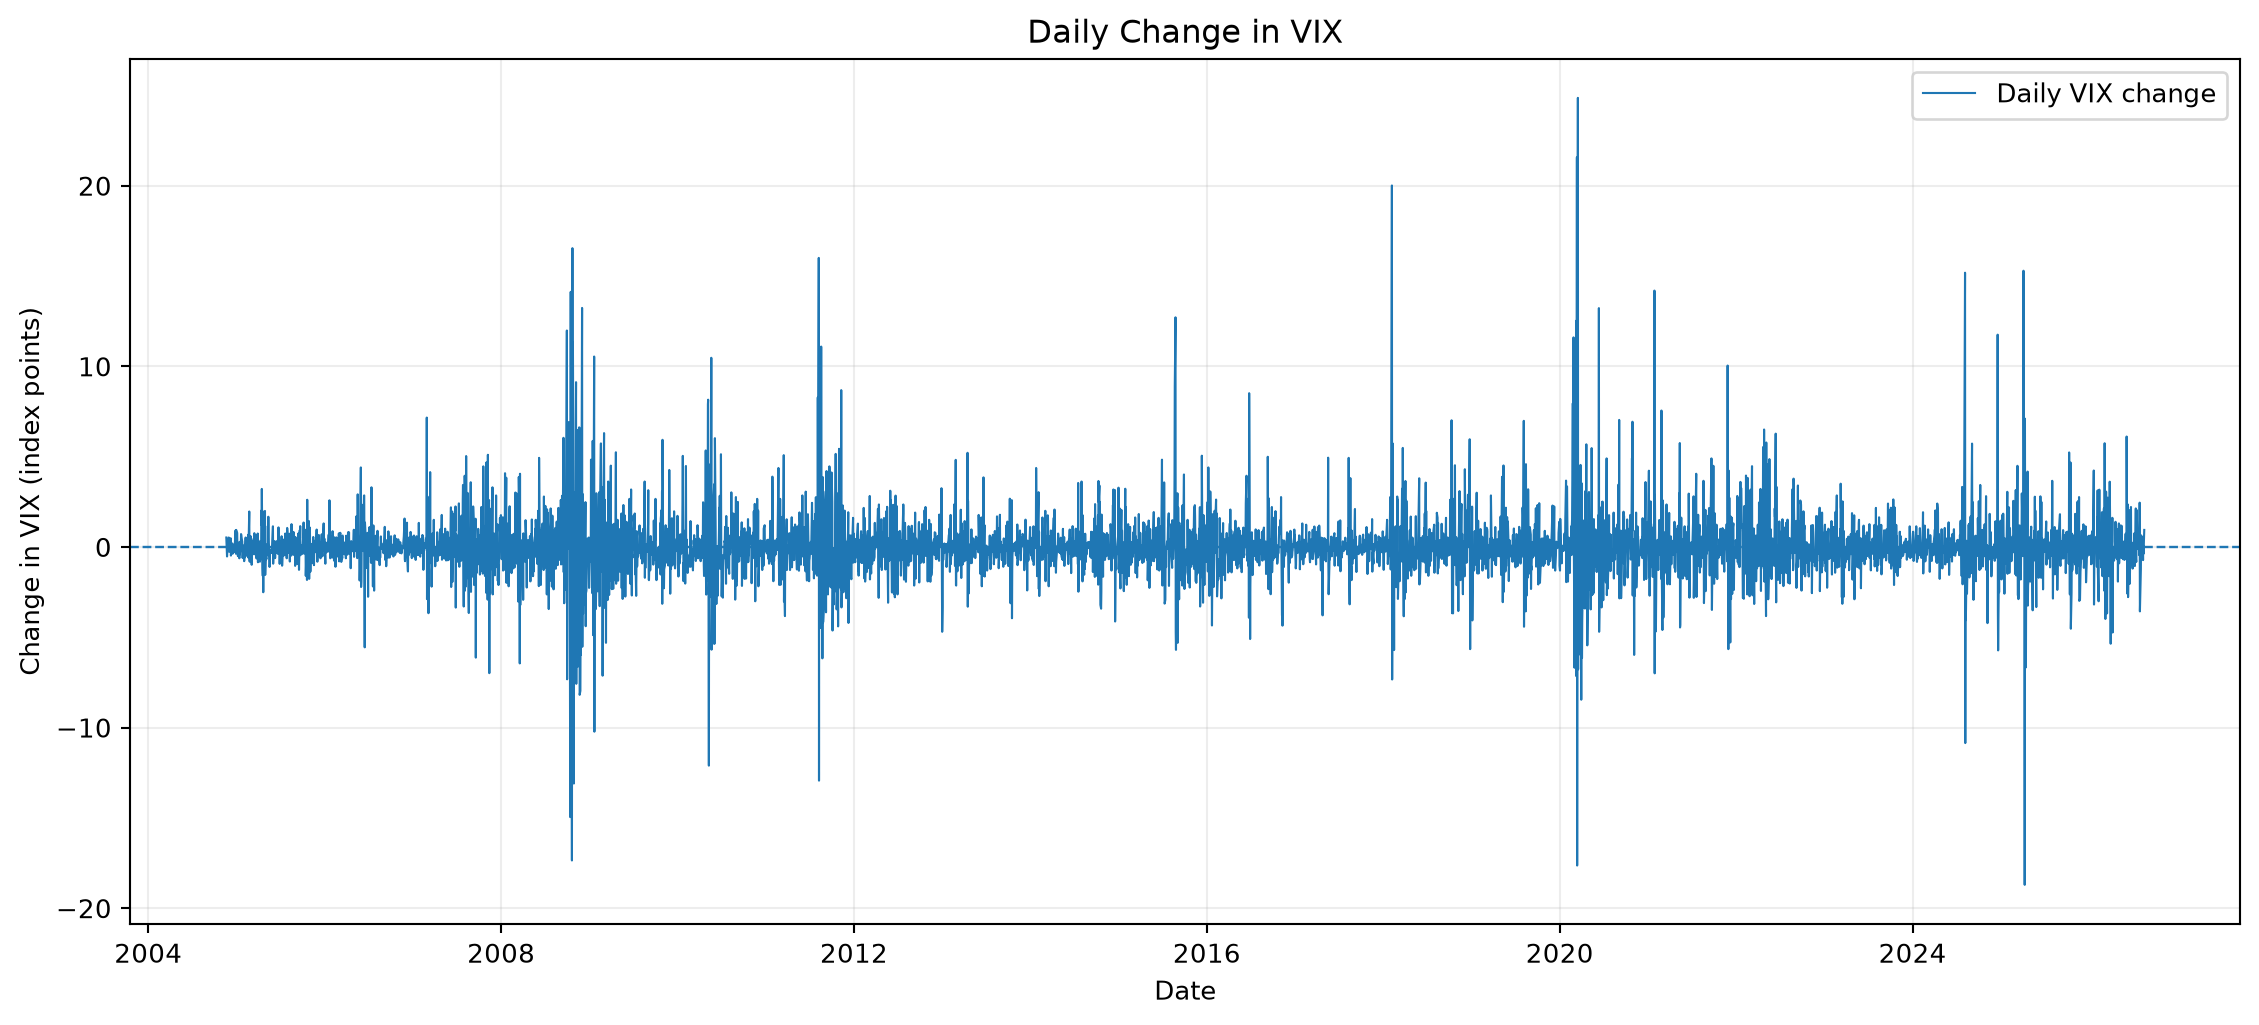

In [3]:
nb.show_step1_figures()

### Interpretation of the exploratory figures

The ETF return series fluctuate around zero and exhibit volatility clustering and occasional large observations. VIX changes are much more visibly heavy-tailed: ordinary days are concentrated near zero, while crisis periods generate large positive jumps and subsequent reversals. This asymmetry is economically important because an allocation rule based on VIX changes is designed to react to changes in perceived market stress rather than to the absolute VIX level alone.


## 2. Regime modeling
### 2.1 Quantile-discretized Markov chain

For each candidate state count \(K\in\{2,3\}\), the empirical distribution of daily VIX changes is partitioned by sample quantiles. With \(K=2\), the median separates the two states. With \(K=3\), the one-third and two-thirds quantiles produce three ordered states. An observation exactly equal to a cut point is assigned to the higher state, which makes the state-definition rule deterministic.

If \(N_{ij}\) is the number of observed transitions from state \(i\) to state \(j\), the maximum-likelihood transition estimate is

\[
\widehat P_{ij}=\frac{N_{ij}}{\sum_{m=0}^{K-1}N_{im}}.
\]

**Greek letter used below:** \(\pi\) — *pi* — denotes the stationary state-probability row vector.

A stationary distribution satisfies

\[
\boldsymbol{\pi}\widehat P=\boldsymbol{\pi},
\qquad
\sum_{j=0}^{K-1}\pi_j=1.
\]

The stationary vector is a long-run probability description implied by the estimated transition matrix; it is not a forecast that the market will remain permanently in those proportions.


**Quantile Markov specification, K=2**

,state,lower_bound,upper_bound
0,0,-inf,-0.099999
1,1,-0.099999,inf


,from_state,state_0,state_1
0,0,0.479266,0.520734
1,1,0.518072,0.481928


,state,stationary_probability
0,0,0.498719
1,1,0.501281


**Quantile Markov specification, K=3**

,state,lower_bound,upper_bound
0,0,-inf,-0.47
1,1,-0.47,0.30
2,2,0.30,inf


,from_state,state_0,state_1,state_2
0,0,0.349311,0.300826,0.349862
1,1,0.233132,0.431706,0.335162
2,2,0.414020,0.268346,0.317634


,state,stationary_probability
0,0,0.332174
1,1,0.333638
2,2,0.334187


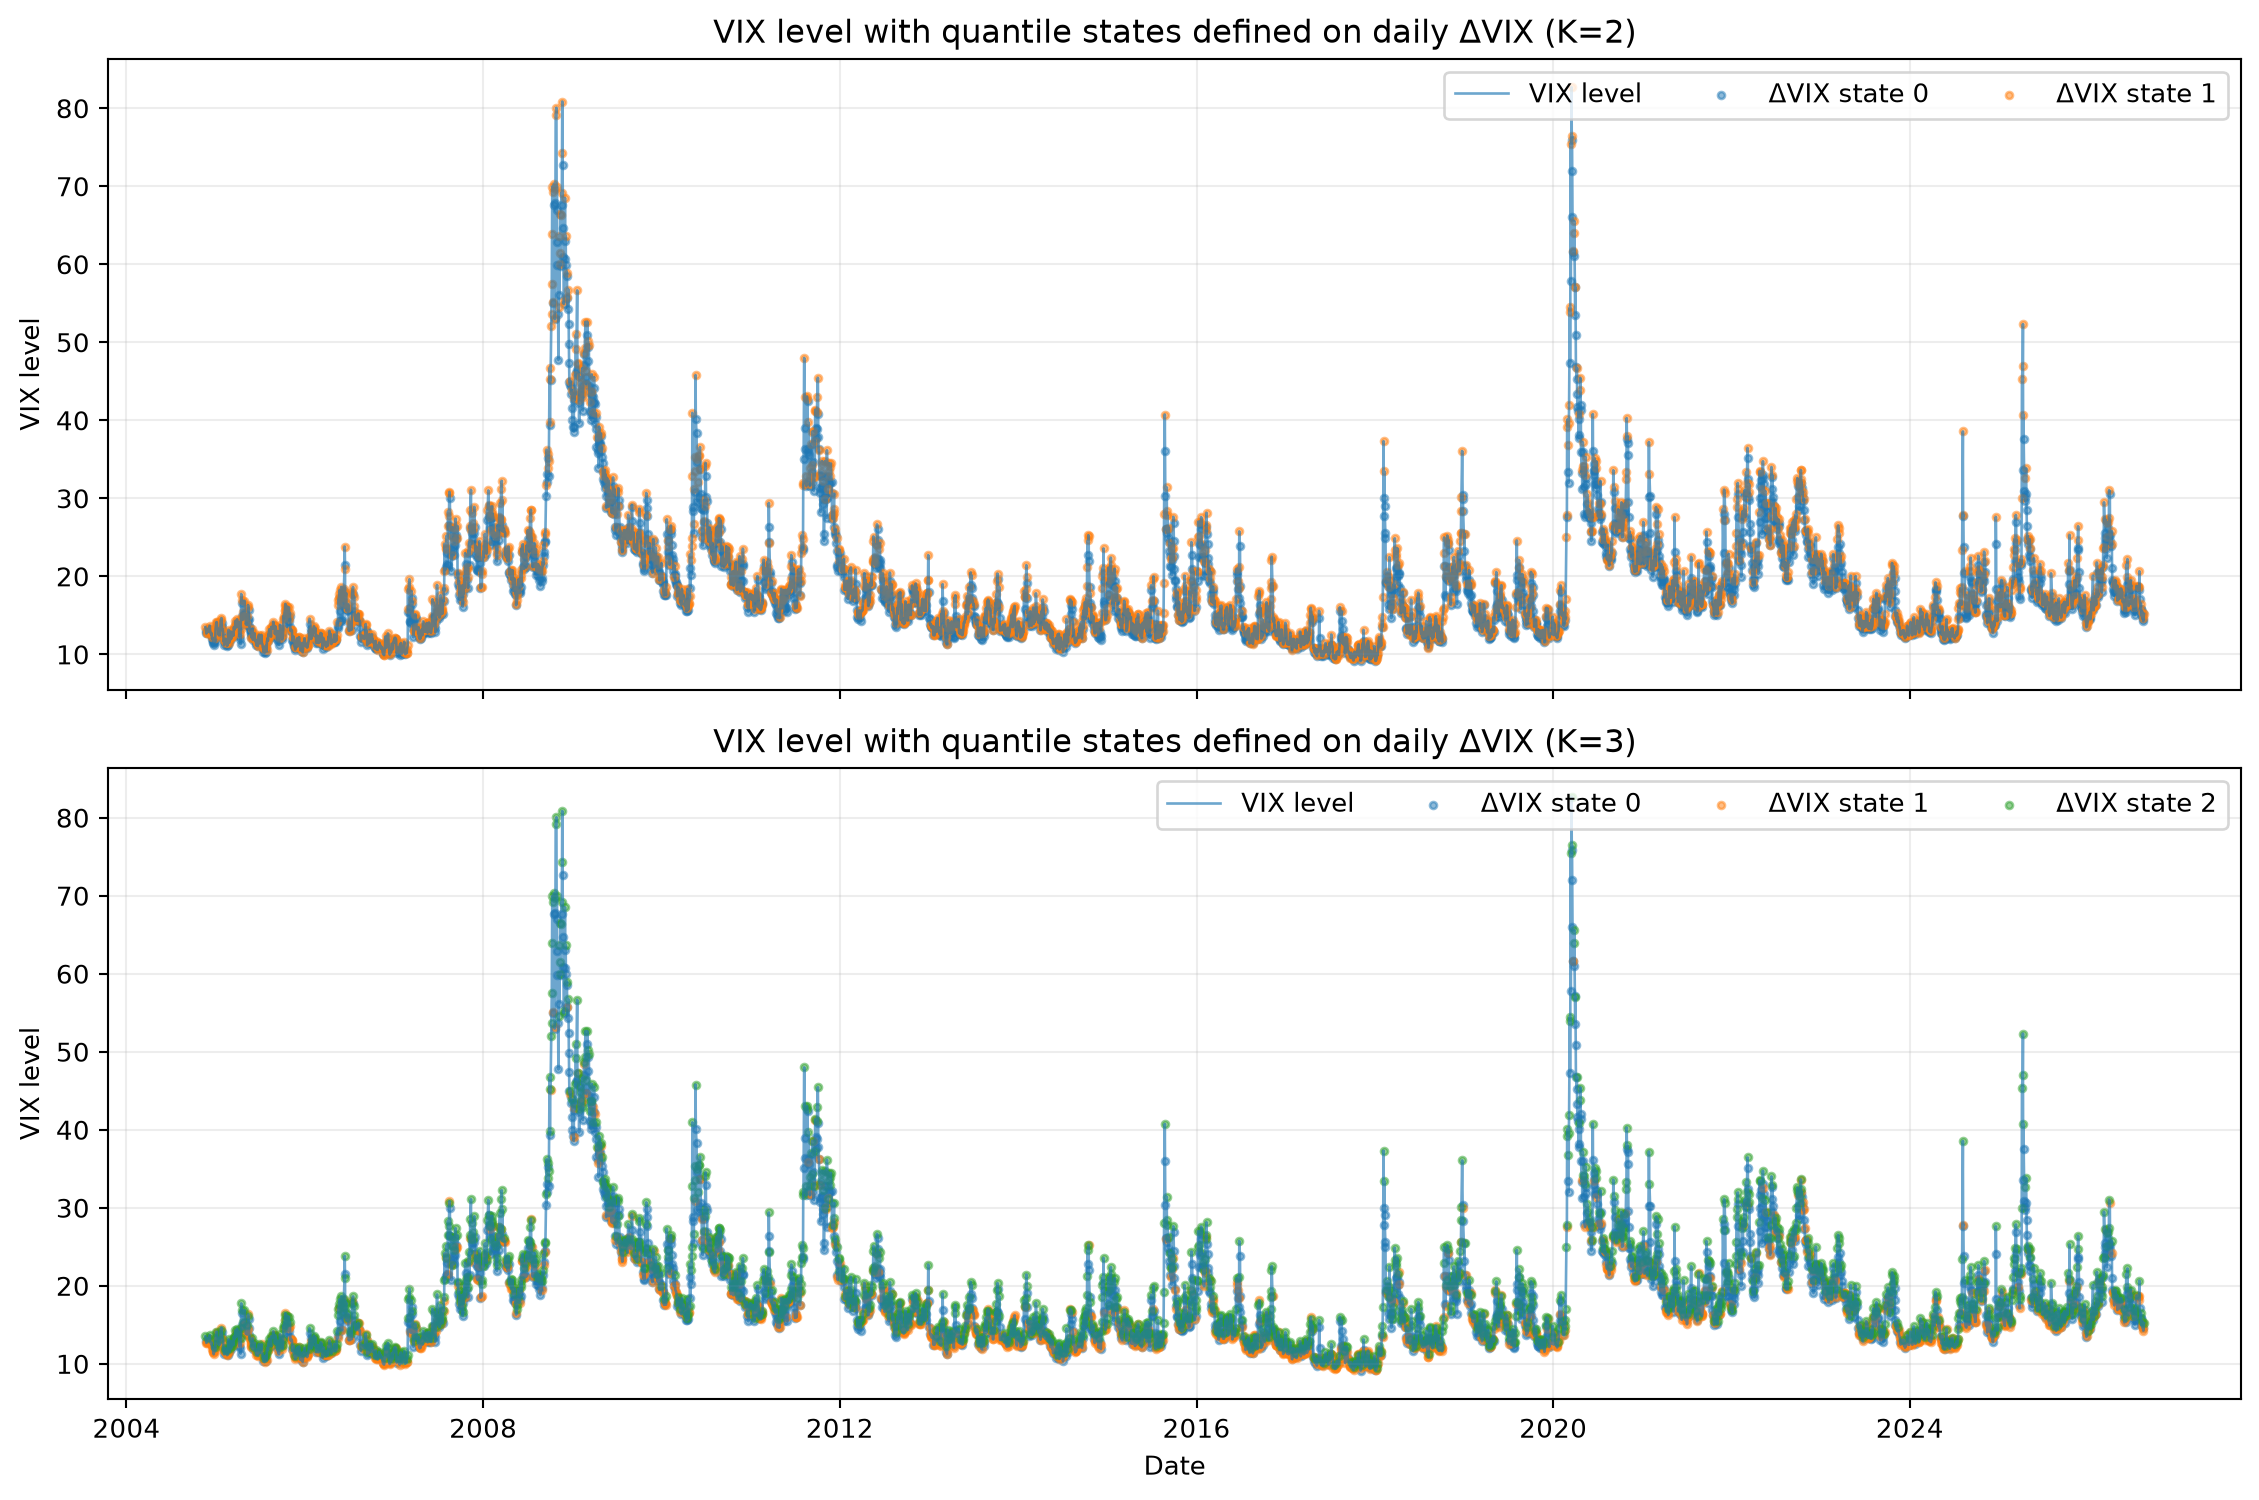

In [4]:
nb.show_step2_markov_results()

### 2.2 Gaussian hidden-state specification

The alternative model treats the observed daily VIX change as generated by an unobserved state process. Conditional on state \(S_t=j\), each observation follows a state-specific Gaussian distribution.

**Greek letters used below:** \(\mu\) — *mu* — is a state-conditional mean; \(\sigma\) — *sigma* — is a state-conditional standard deviation.

\[
X_t\mid S_t=j\sim\mathcal N(\mu_j,\sigma_j^2),
\qquad X_t=\Delta VIX_t.
\]

The hidden state follows a first-order Markov transition law,

\[
P(S_t=j\mid S_{t-1}=i)=p_{ij}.
\]

Parameters are estimated by likelihood maximization with deterministic multiple restarts. The fitted states are relabeled by increasing state-conditional mean VIX change, so state numbering has an economically consistent interpretation across candidate fits. The Viterbi sequence is the single most likely state path under the fitted model, whereas the smoothed posterior probabilities quantify uncertainty in state membership after conditioning on the full observed sequence (Baum et al. 164–171; Rabiner 257–286; Viterbi 260–269).

<!-- citekey: baum1970maximization -->
<!-- citekey: rabiner1989tutorial -->
<!-- citekey: viterbi1967decoding -->


**Gaussian HMM specification, K=2**

,state,mean_vix_change,variance_vix_change,start_probability,viterbi_observations,viterbi_occupancy,posterior_mean_probability
0,0,-0.074387,0.654348,1.000000e+00,4159,0.761025,0.739429
1,1,0.212640,11.957452,1.034965e-36,1306,0.238975,0.260571


,from_state,state_0,state_1
0,0,0.958717,0.041283
1,1,0.117102,0.882898


**Gaussian HMM specification, K=3**

,state,mean_vix_change,variance_vix_change,start_probability,viterbi_observations,viterbi_occupancy,posterior_mean_probability
0,0,-0.062142,0.384075,1.000000e+00,2900,0.530650,0.521821
1,1,-0.011439,3.118842,9.246767e-101,2306,0.421958,0.421097
2,2,0.659519,36.347398,3.003336e-208,259,0.047392,0.057082


,from_state,state_0,state_1,state_2
0,0,9.388732e-01,0.059776,0.001351
1,1,7.568002e-02,0.908619,0.015701
2,2,1.193886e-23,0.128159,0.871841


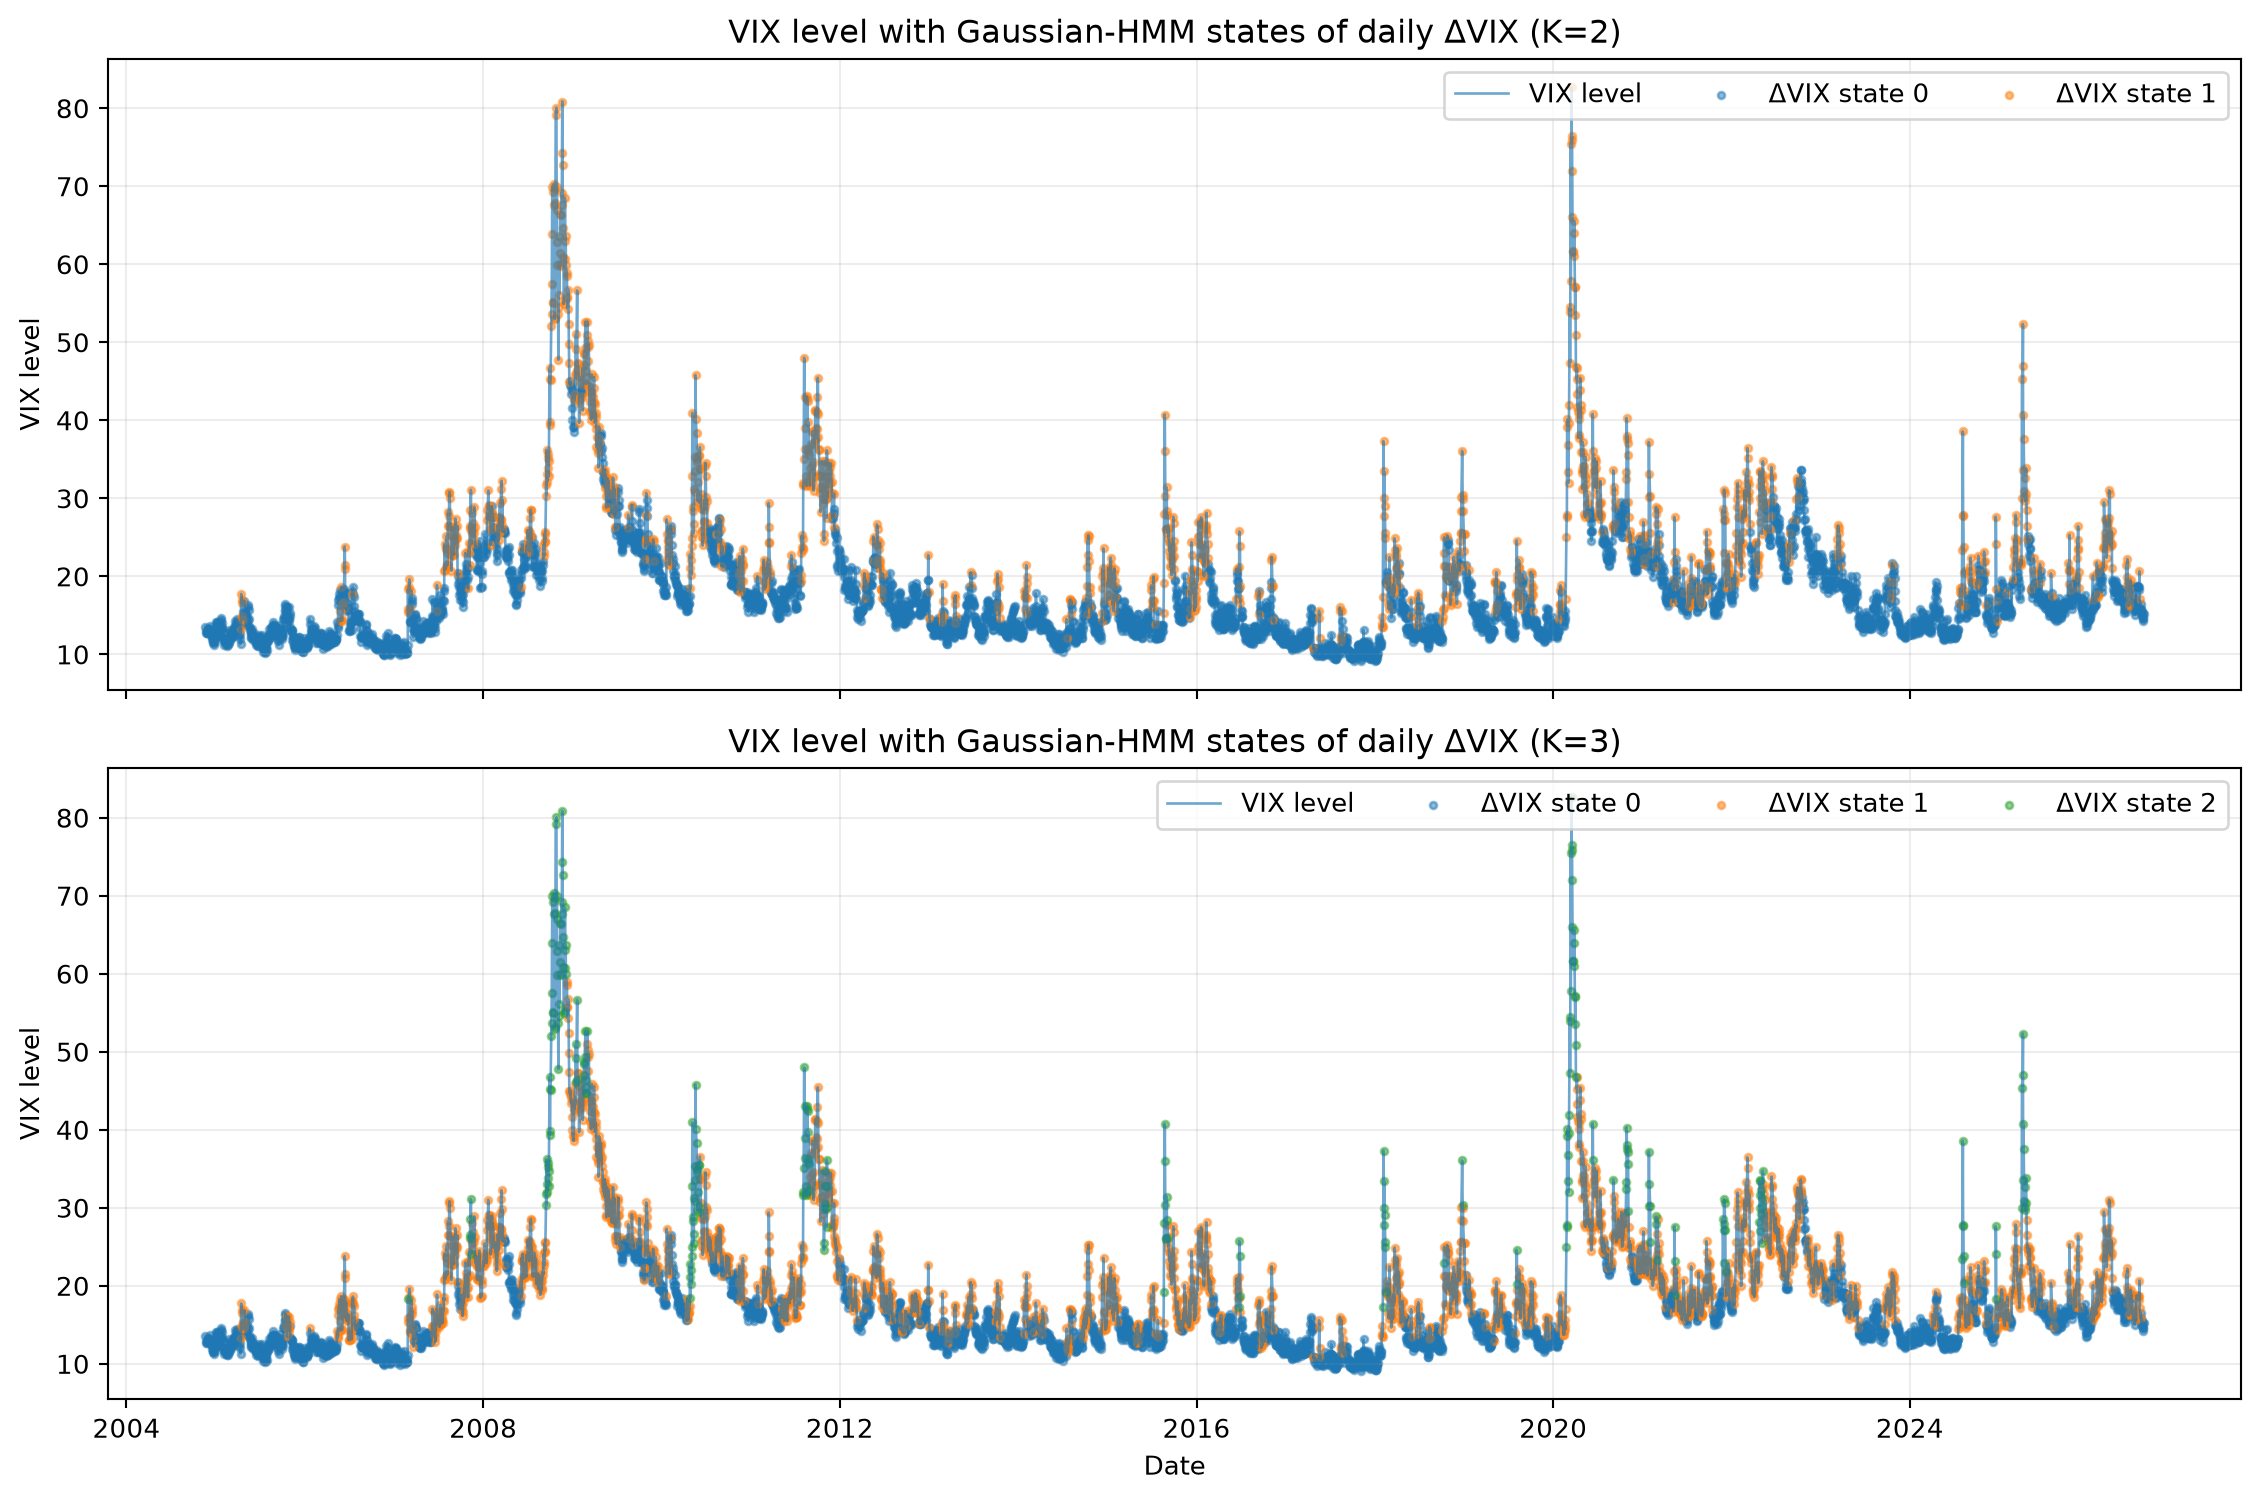

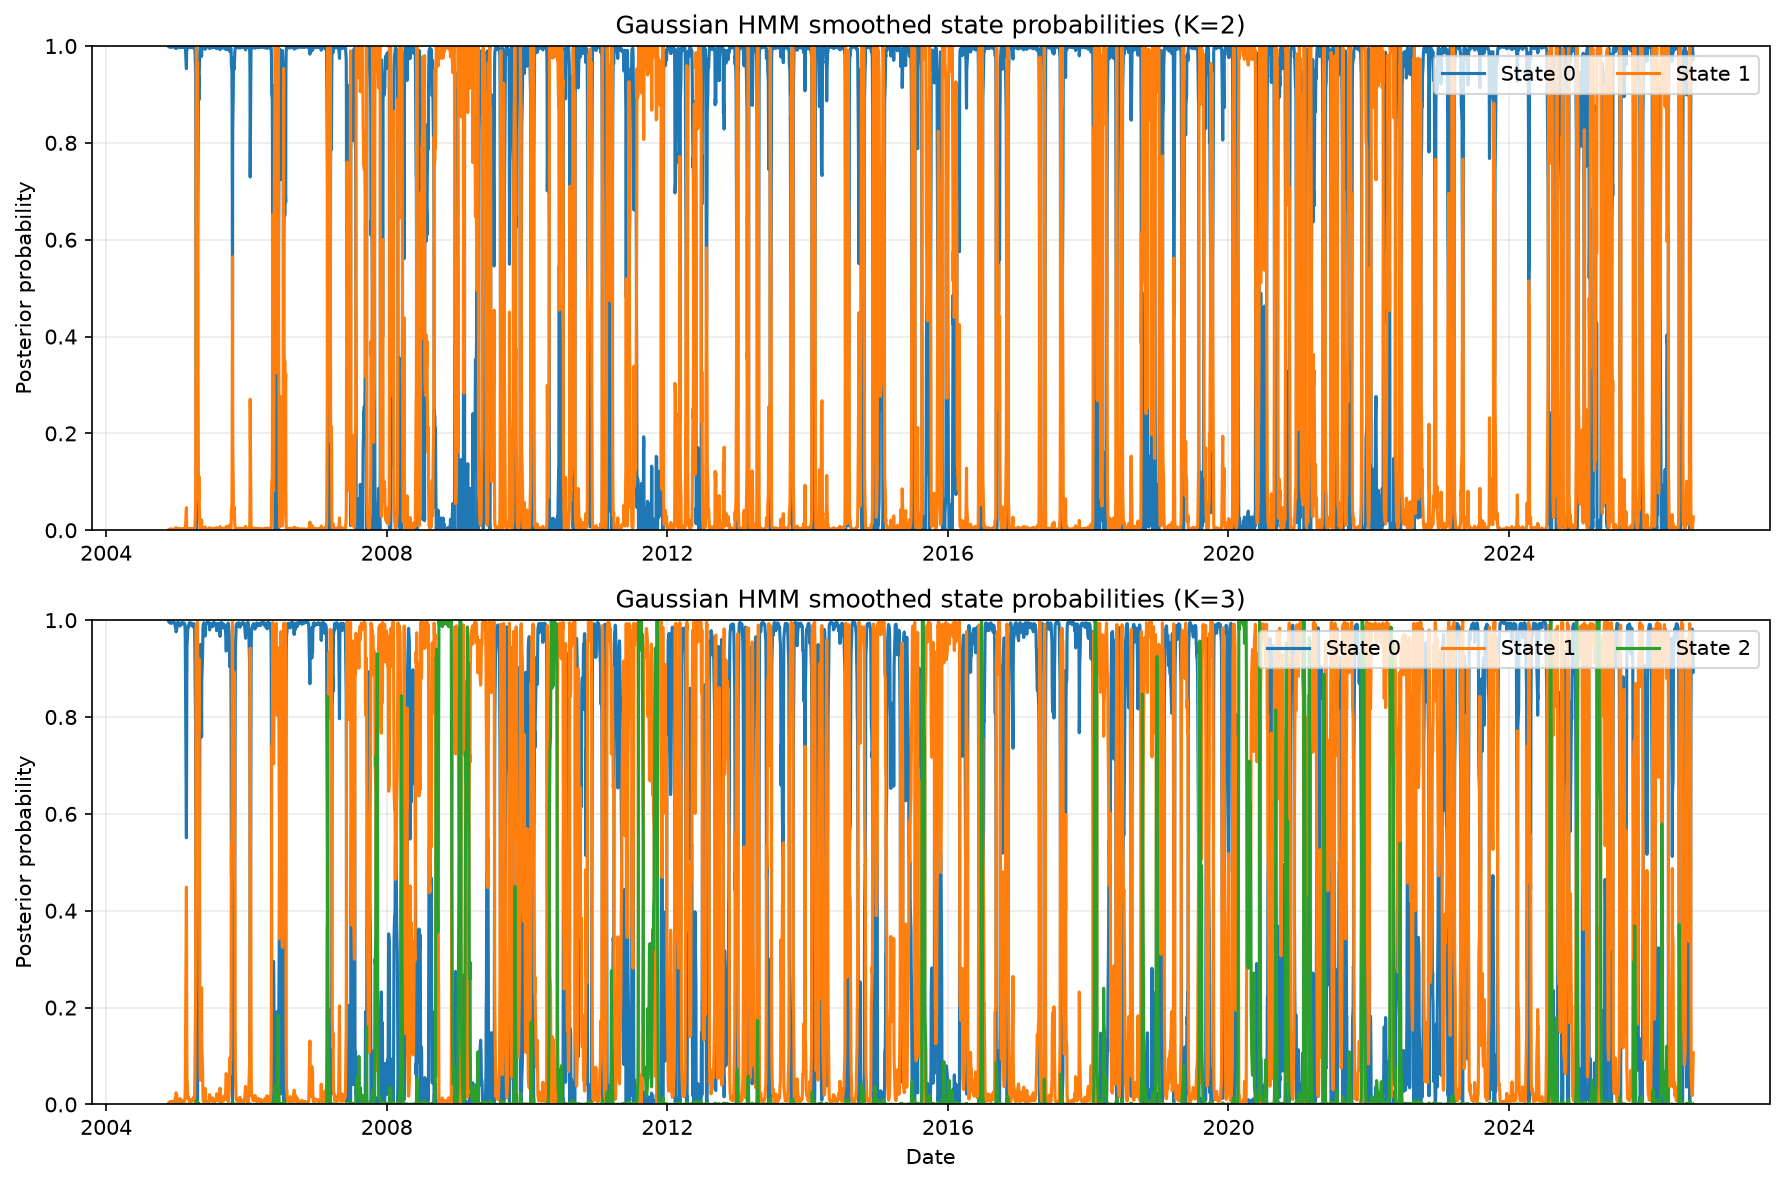

In [5]:
nb.show_step2_hmm_results()

## 3. Model comparison and economic state interpretation

For a candidate with maximized log-likelihood \(\ell\), parameter count \(k\), and observation count \(n\), the information criteria are

\[
AIC=2k-2\ell,
\qquad
BIC=k\ln(n)-2\ell.
\]

Lower values indicate a better likelihood-versus-complexity trade-off within a comparable likelihood family (Akaike 716–723; Schwarz 461–464). In this project, the quantile Markov likelihood is defined on a discretized transition sequence while the hidden-state likelihood is defined on the continuous VIX-change observations. Therefore the raw AIC/BIC magnitudes are **not** interpreted as a statistically valid cross-family ranking. BIC selects the preferred state count within each family; the pre-declared diagnostic rule then determines which family supplies the allocation states.

<!-- citekey: akaike1974identification -->
<!-- citekey: schwarz1978dimension -->


In [6]:
nb.show_step3_model_selection()

**Candidate comparison; information criteria are interpreted within family**

,family,n_states,log_likelihood,n_parameters,n_observations,aic,bic,converged,criterion_scope
0,markov,2,-3783.223040,2,5464,7570.446081,7583.657954,True,within_family_only
1,markov,3,-5913.883847,6,5464,11839.767693,11879.403312,True,within_family_only
2,hmm,2,-9306.004199,7,5465,18626.008398,18672.251234,True,within_family_only
3,hmm,3,-8959.534974,14,5465,17947.069948,18039.555620,True,within_family_only


**Selected-model provenance**

,family,n_states,state_source,selection_reason,markov_best_n_states,hmm_best_n_states,input_data_sha256,selected_states_path
0,markov,2,reports/tables/step2_markov_2_states.csv,"Within-family BIC selected HMM K=3, but at lea...",2,3,c6b0e67a145f809313986ca0ef726d1dd42ffdaf57b04f...,reports/tables/step3_selected_states.csv


**Decision-rule outcome.** Within-family BIC selected HMM K=3, but at least one decoded HMM state has occupancy below 5%; the fixed fallback selects Markov K=2.

The HMM fallback is a **project diagnostic rule**, not proof that the candidate is statistically impossible. Its smallest decoded state has occupancy **4.7392%**, which is only **0.2608 percentage points** below the fixed 5% threshold.

### State-conditional ETF moments

For state \(s\), asset \(i\), and \(n_s\) observations, the conditional daily mean log return is

\[
\bar r_{i,s}=\frac{1}{n_s}\sum_{t:S_t=s} r_{i,t},
\]

and the sample standard deviation is

\[
s_{i,s}=\sqrt{\frac{1}{n_s-1}\sum_{t:S_t=s}\left(r_{i,t}-\bar r_{i,s}\right)^2}.
\]

The plotted error bars are **sample standard deviations**, not standard errors or confidence intervals. They therefore describe the dispersion of daily returns within a state rather than statistical uncertainty around the estimated conditional mean.


**State-conditional ETF daily log-return statistics**

,state,asset,mean_log_return,std_log_return,observations
0,0,TLT,-0.001257,0.008854,2725
1,0,GLD,0.000860,0.010878,2725
2,0,SPY,0.006702,0.009337,2725
3,1,TLT,0.001478,0.009249,2740
4,1,GLD,-0.000048,0.012056,2740
5,1,SPY,-0.005836,0.010843,2740


**Conditional-mean leaders**

- State 0: **SPY** has the largest historical conditional mean, 67.018 basis points per day.
- State 1: **TLT** has the largest historical conditional mean, 14.777 basis points per day.

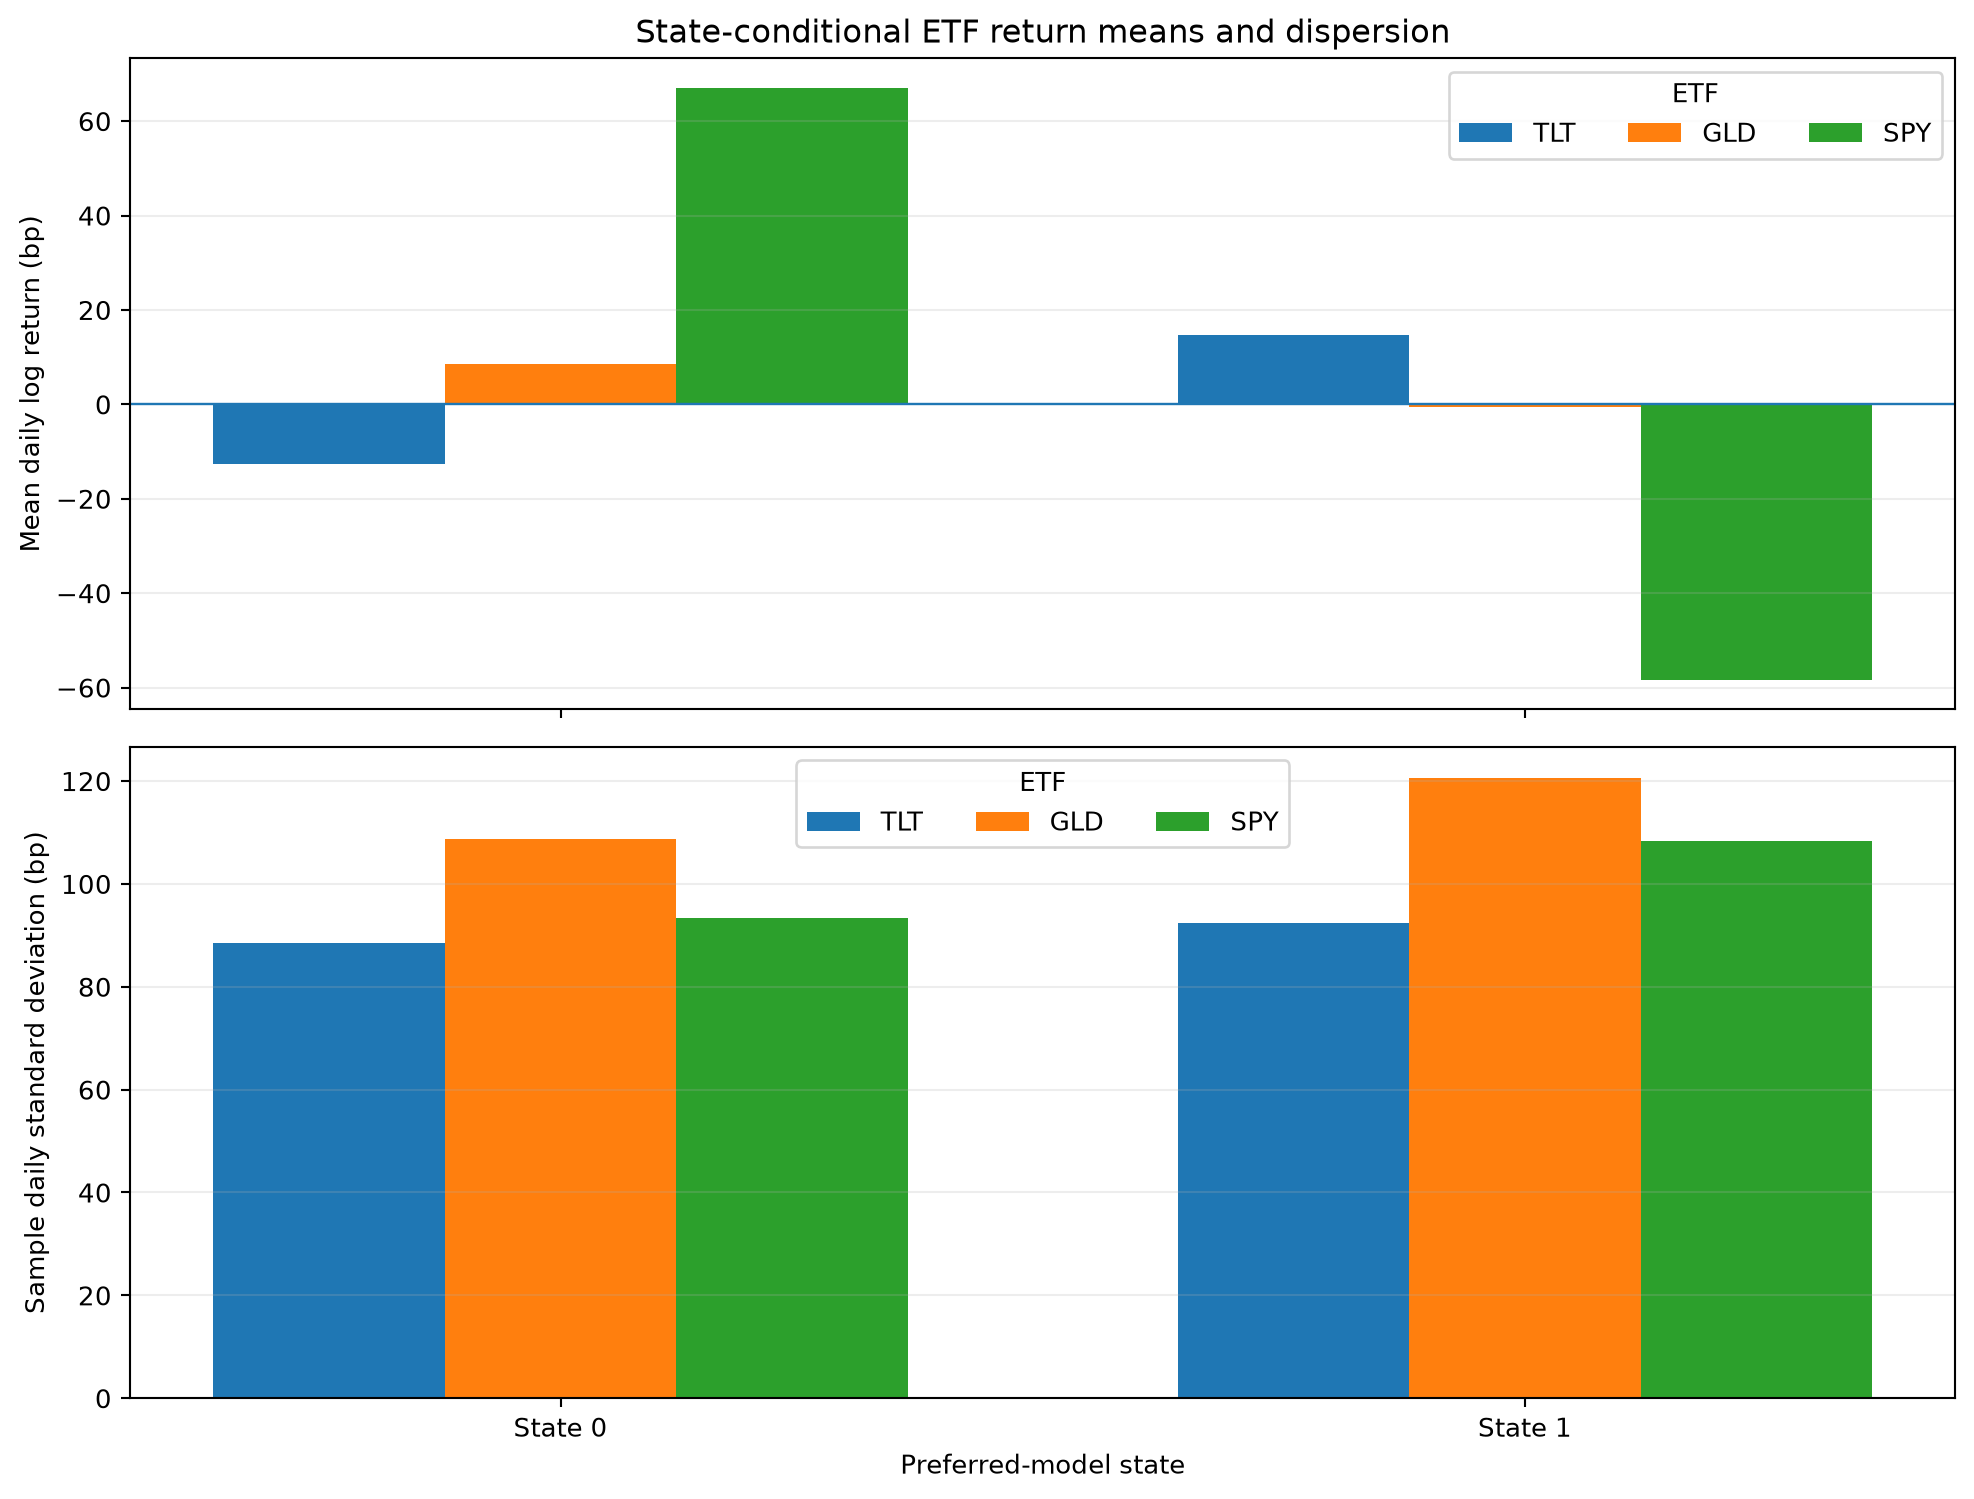

In [7]:
nb.show_step3_state_statistics()

## 4. State-based allocation rule

For every preferred state \(s\), the allocation assigns 100% of capital to the ETF with the largest historical state-conditional mean log return:

\[
a^*(s)=\operatorname*{arg\,max}_{a\in\{TLT,GLD,SPY\}}\bar r_{a,s}.
\]

The corresponding portfolio weight is

\[
w_a(s)=\mathbf 1\{a=a^*(s)\}.
\]

Exact ties are resolved by the fixed priority TLT, then GLD, then SPY. This deterministic rule makes the mapping reproducible, but it is deliberately concentrated rather than diversified. Markowitz's portfolio framework reminds us that maximizing a conditional mean alone does not control covariance or total portfolio risk (Markowitz 77–91).

<!-- citekey: markowitz1952portfolio -->


In [8]:
nb.show_step4_allocation()

**Deterministic state-to-allocation mapping**

,state,selected_asset,selection_mean_log_return,TLT_weight,GLD_weight,SPY_weight
0,0,SPY,0.006702,0.0,0.0,1.0
1,1,TLT,0.001478,1.0,0.0,0.0


The implemented mapping is **State 0 → SPY, State 1 → TLT**. Because each row is one-hot, the strategy is fully concentrated in a single ETF at every decision date.

## 5. Backtest and evaluation
### One-observed-row execution lag

The state observed on trading row \(t-1\) determines the weights applied to the ETF returns on row \(t\). ETF log returns are first converted to simple returns before portfolio aggregation:

\[
R_{i,t}=e^{r_{i,t}}-1,
\qquad
R^{rot}_t=\sum_i w_i(S_{t-1})R_{i,t}.
\]

This lag prevents using the same row's state to select the same row's return. It does **not**, by itself, create an out-of-sample experiment because the regime definitions and state-conditional allocation means were estimated from the full sample.

### Benchmarks
The comparison uses exactly two benchmarks on the same return dates: (1) one-third TLT, one-third GLD, and one-third SPY, reset to equal weights at the first observed trading date of each calendar month and allowed to drift intra-month; and (2) SPY buy-and-hold.

### Performance measures
With initial wealth \(W_0=1\) and daily simple portfolio return \(R_t\),

\[
W_T=\prod_{t=1}^{T}(1+R_t),
\qquad
CR=W_T-1.
\]

Annualized return is

\[
AR=W_T^{252/T}-1,
\]

annualized volatility is

\[
AV=s_R\sqrt{252},
\]

and the zero-risk-free Sharpe ratio is

\[
SR=\frac{\bar R}{s_R}\sqrt{252}.
\]

Maximum drawdown uses the running wealth peak including \(W_0=1\):

\[
MDD=\min_t\left(\frac{W_t}{\max_{0\le u\le t}W_u}-1\right).
\]

Including initial wealth is necessary so that an immediate first-period loss is correctly recognized as a drawdown.


**Step 5 performance summary**

,portfolio,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,observations
0,regime_rotation,84.90%,2.88%,16.04%,0.257,-53.76%,5464
1,equal_weight_monthly,542.08%,8.95%,9.71%,0.932,-23.04%,5464
2,spy_buy_hold,879.81%,11.10%,18.88%,0.652,-55.19%,5464


**Economic interpretation.** The lagged regime rotation is not competitive with either required benchmark on this historical sample. It earns **2.88% annualized** with Sharpe **0.257**, versus **8.95% / 0.932** for monthly equal weight and **11.10% / 0.652** for SPY. The equal-weight benchmark also has the smallest maximum drawdown at **-23.04%**. This is consistent with the distinction between a strong same-day state/return association and genuinely useful next-observation predictive information.

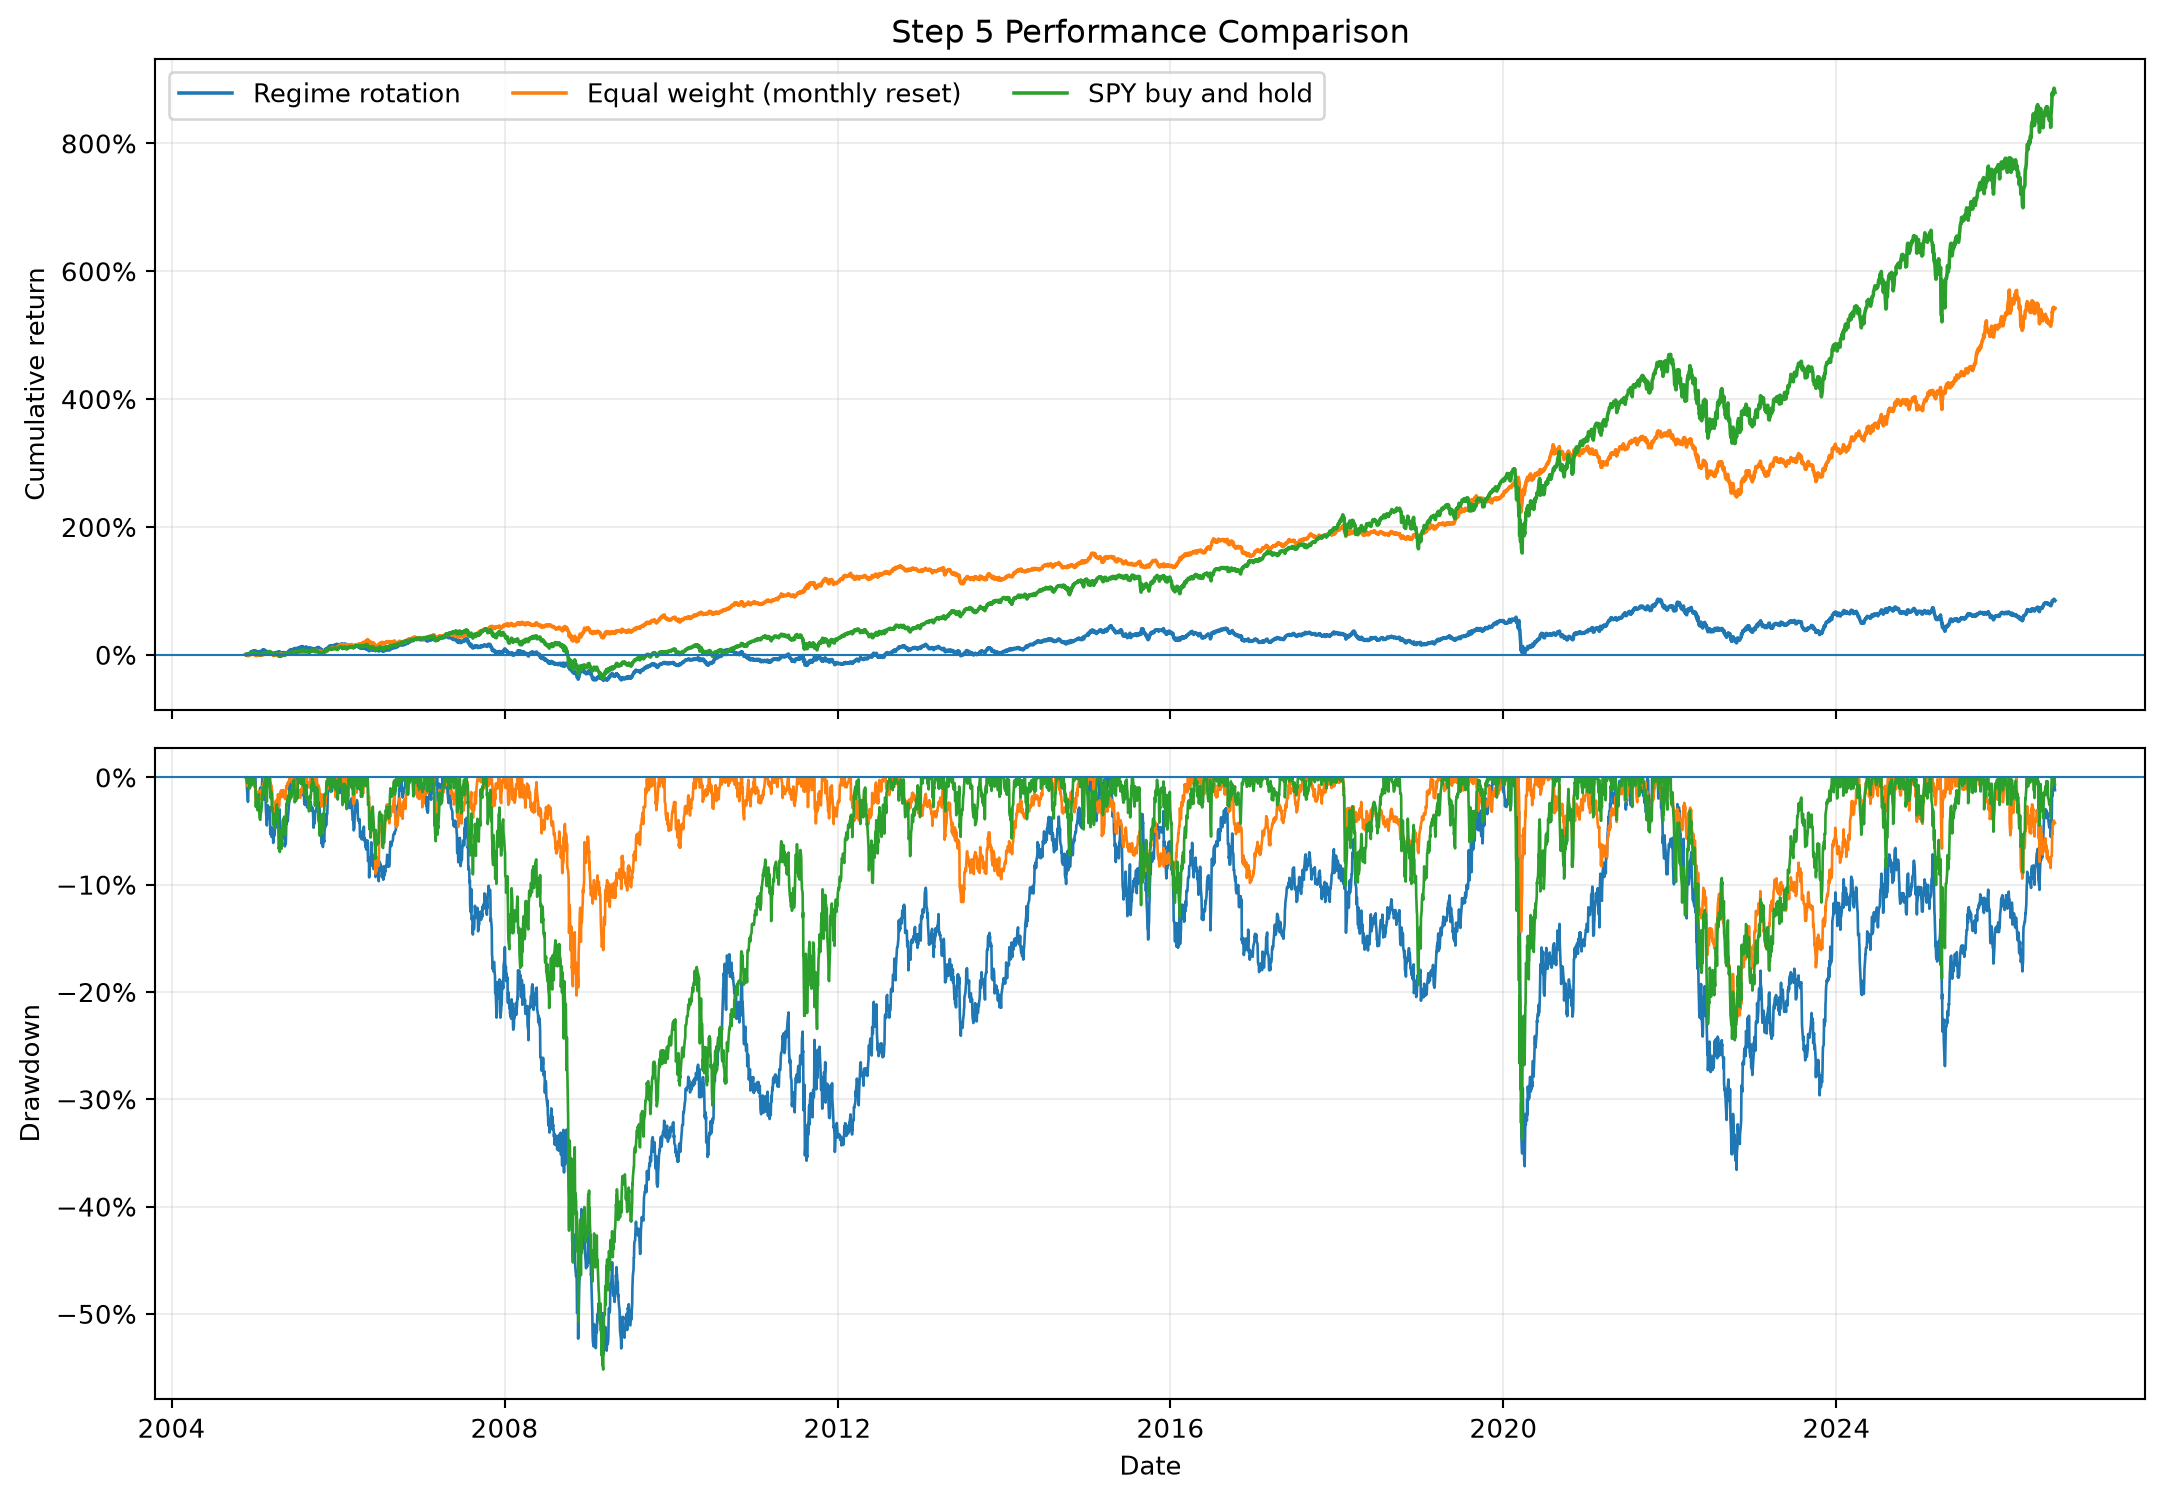

In [9]:
nb.show_step5_backtest()

### State-count sensitivity

The final sensitivity check compares \(K=2\) and \(K=3\) **within the already selected model family** on a common lagged-return date intersection. It is a robustness description, not a second model-selection exercise, and it must not replace the Step 3 selection rule merely because one historical backtest row performs better.


In [10]:
nb.show_step5_sensitivity()

,family,n_states,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,observations
0,markov,2,0.849021,0.028754,0.160369,0.257204,-0.537600,5464
1,markov,3,0.762162,0.026473,0.163043,0.242167,-0.650533,5464


The highest historical Sharpe ratio in this sensitivity table occurs at **K=2**, but this is a robustness comparison only; it does not replace the pre-declared Step 3 state-count selection rule.

## 6. Interpretation, limitations, and practitioner implications

The project demonstrates that VIX-change states can be converted into a transparent allocation policy, but the historical backtest must be interpreted cautiously. The full-sample regime thresholds or fitted parameters, the full-sample state sequence, and the full-sample state-conditional ETF means all use information unavailable at earlier decision dates. The required one-row trading lag corrects same-row execution timing but does not remove that estimation look-ahead.

A stronger production study would use rolling or expanding estimation, one-sided state inference, allocation means estimated only from information available at each decision date, explicit transaction costs and turnover, and repeated robustness checks across samples. White emphasizes the danger of data-snooping inference, while Bailey and López de Prado show that conventional Sharpe-ratio interpretation can be badly distorted by selection bias and backtest overfitting (White 1097–1126; Bailey and López de Prado 94–107).

<!-- citekey: white2000datasnooping -->
<!-- citekey: bailey2014deflatedsharpe -->

From a Financial Engineering perspective, the key contribution is the separation of four distinct layers: state inference, conditional return estimation, deterministic allocation, and performance evaluation. That separation makes it possible to replace any single layer—such as the regime model or allocation objective—without changing the rest of the research pipeline.


## Works Cited

Akaike, Hirotugu. “A New Look at the Statistical Model Identification.” *IEEE Transactions on Automatic Control*, vol. 19, no. 6, 1974, pp. 716–723. doi:10.1109/TAC.1974.1100705.

Bailey, David H., and Marcos López de Prado. “The Deflated Sharpe Ratio: Correcting for Selection Bias, Backtest Overfitting, and Non-Normality.” *The Journal of Portfolio Management*, vol. 40, no. 5, 2014, pp. 94–107. doi:10.3905/jpm.2014.40.5.094.

Baum, Leonard E., et al. “A Maximization Technique Occurring in the Statistical Analysis of Probabilistic Functions of Markov Chains.” *The Annals of Mathematical Statistics*, vol. 41, no. 1, 1970, pp. 164–171. doi:10.1214/aoms/1177697196.

Cboe Global Markets. “Cboe VIX FAQ.” *Cboe Global Markets*, 2019. Accessed 19 Aug. 2026.

Markowitz, Harry. “Portfolio Selection.” *The Journal of Finance*, vol. 7, no. 1, 1952, pp. 77–91. doi:10.1111/j.1540-6261.1952.tb01525.x.

Rabiner, Lawrence R. “A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition.” *Proceedings of the IEEE*, vol. 77, no. 2, 1989, pp. 257–286. doi:10.1109/5.18626.

Schwarz, Gideon. “Estimating the Dimension of a Model.” *The Annals of Statistics*, vol. 6, no. 2, 1978, pp. 461–464. doi:10.1214/aos/1176344136.

Viterbi, Andrew J. “Error Bounds for Convolutional Codes and an Asymptotically Optimum Decoding Algorithm.” *IEEE Transactions on Information Theory*, vol. 13, no. 2, 1967, pp. 260–269. doi:10.1109/TIT.1967.1054010.

Whaley, Robert E. “Understanding the VIX.” *The Journal of Portfolio Management*, vol. 35, no. 3, 2009, pp. 98–105. doi:10.3905/JPM.2009.35.3.098.

White, Halbert. “A Reality Check for Data Snooping.” *Econometrica*, vol. 68, no. 5, 2000, pp. 1097–1126. doi:10.1111/1468-0262.00152.
